# Accumulated Local Effects (ALE) Analysis for EMC Dataset

This notebook analyzes the accumulated local effects on the same feature set as the SHAP analysis.
We use Leave-One-Subject-Out (LOSO) cross-validation with proper ALE computation:

1. For each fold, fit the full pipeline on training subjects
2. Compute quantile bins on training data of that fold
3. Compute ALE curve on training data using the fitted model
4. Aggregate across folds with proper interpolation and weighting

In [ ]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

plt.style.use('ggplot')

DATA_FOLDER = '/space/gzanardini/emc_whole/split'
# Best parameters from SHAP analysis
best_parameters = {
    'spectral': ('Cz', 10, 'std'),
    'cwt': ('BipolarDB', 2, 'median'),
    'dwt': ('Laplacian', 10, 'median'),
    'mst': ('BipolarDB', 60, 'median'),
    'sst': ('CAR', 10, 'median'),
    'cc': ('CAR', 1, 'std'),
    'plv': ('Laplacian', 60, 'kurt'),
    'gcc': ('CAR', 60, 'median'),
    'gplv': ('Laplacian', 2, 'std'),
    'utm': ('Laplacian', 20, 'std'),
}

In [2]:
from functools import partial
import sys
from pathlib import Path
# Ensure the workspace root is on sys.path so local packages (like `utils`) are importable
cwd = Path.cwd()
project_root = None
for parent in [cwd] + list(cwd.parents):
    if (parent / 'utils').is_dir() or (parent / '.git').exists():
        project_root = str(parent)
        break
if project_root is None:
    project_root = str(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils.plotting import (
    aggregate_ale_across_folds,
    compute_ale_1d,
    compute_mann_whitney_features,
    interpolate_ale_to_common_grid,
    load_feature_data_from_best_params,
    load_subject_data,
    plot_ale_from_data,
    plv_index_to_name,
    prepare_ale_plot_data,
)

load_data = partial(load_subject_data, DATA_FOLDER)
load_feature_data = partial(load_feature_data_from_best_params, DATA_FOLDER, best_parameters)

In [3]:
# Load data
description, labels, subjects, unique_subjects, subject_labels = load_data()

# Load PLV feature data using best parameters
feature_name = 'plv'
data, montage, segment_length, combiner = load_feature_data(feature_name)

# Channel names for PLV feature naming
chs = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
       'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2']

feature_names = [plv_index_to_name(i, channels=chs) for i in range(data.shape[1])]
print(f"Loaded {feature_name} data: {data.shape}")
print(f"Montage: {montage}, Segment length: {segment_length}s, Combiner: {combiner}")

Loaded plv data: (141, 1026)
Montage: Laplacian, Segment length: 60s, Combiner: kurt


In [4]:
# Compute Mann-Whitney U test for top 5 features only
print("=== MANN-WHITNEY U FEATURE SELECTION ===")
top_features, mw_p_values, mw_corrected_p_values = compute_mann_whitney_features(data, labels, top_n=4)

print(f"\nTop 5 features with lowest Bonferroni-corrected p-values:")
for i, feat_idx in enumerate(top_features):
    p_val = mw_p_values[feat_idx]
    corrected_p_val = mw_corrected_p_values[feat_idx]
    if feat_idx < len(feature_names):
        feat_name = feature_names[feat_idx]
    else:
        feat_name = f"Feature_{feat_idx}"
    
    print(f"  {i+1}. Feature {feat_idx}: {feat_name}")
    print(f"      Original p-value: {p_val:.2e}, Corrected p-value: {corrected_p_val:.2e}")

# Set features to analyze to only the top 5 + features 232, 224, and 587
features_to_analyze = top_features #np.concatenate([top_features, [232, 224, 587]])
print(f"Total features to analyze: {len(features_to_analyze)}")

=== MANN-WHITNEY U FEATURE SELECTION ===


Computing Mann-Whitney U tests: 100%|██████████| 1026/1026 [00:00<00:00, 2180.77it/s]


Top 5 features with lowest Bonferroni-corrected p-values:
  1. Feature 232: PLV_delta_FP2-T5
      Original p-value: 3.39e-04, Corrected p-value: 3.48e-01
  2. Feature 327: PLV_delta_O2-P3
      Original p-value: 3.83e-04, Corrected p-value: 3.93e-01
  3. Feature 97: PLV_raw_P4-T5
      Original p-value: 7.31e-04, Corrected p-value: 7.50e-01
  4. Feature 0: PLV_raw_F3-FP1
      Original p-value: 4.49e-01, Corrected p-value: 1.00e+00
Total features to analyze: 4


In [5]:
# Compute ALE for Mann-Whitney U selected top 5 features
print("\n=== ALE ANALYSIS FOR TOP 5 MANN-WHITNEY U SELECTED FEATURES ===")
ale_results = {}

for feat_idx in tqdm.tqdm(features_to_analyze, desc='Computing ALE for top 5 features'):
    if feat_idx >= data.shape[1]:
        print(f"Skipping feature {feat_idx}: Index out of range")
        continue
        
    fold_results = []
    all_feature_values = []  # Collect feature values for rugplot
    
    # LOSO cross-validation
    for subj in tqdm.tqdm(unique_subjects, desc=f'LOSO folds for feature {feat_idx}', leave=False):
        test_indices = np.where(subjects == subj)[0]
        train_indices = np.where(subjects != subj)[0]
        
        X_train, X_test = data[train_indices], data[test_indices]
        y_train, y_test = labels[train_indices], labels[test_indices]
        
        # Collect feature values for rugplot (from training data)
        feature_train = X_train[:, feat_idx]
        all_feature_values.extend(feature_train[~np.isnan(feature_train)])
        
        # Handle missing values in training data
        if np.all(np.isnan(feature_train)) or len(np.unique(feature_train[~np.isnan(feature_train)])) < 3:
            continue
        
        # Train model
        ratio = (len(y_train) - sum(y_train)) / max(sum(y_train), 1)
        
        model = XGBClassifier(
            scale_pos_weight=ratio,
            n_jobs=4,
            device='cpu',
            n_estimators=100,
            max_depth=6,
            subsample=0.9,
            gamma=0.1,
            learning_rate=0.01,
            random_state=42
        )
        
        try:
            model.fit(X_train, y_train)
            
            # Compute ALE for this fold
            ale_values, bin_centers, bin_counts = compute_ale_1d(model, X_train, feat_idx, n_bins=20)
            
            if len(ale_values) > 0:
                fold_results.append((ale_values, bin_centers, bin_counts, len(X_train)))
                
        except Exception as e:
            print(f"Error in fold {subj} for feature {feat_idx}: {e}")
            continue
    
    if len(fold_results) > 2:  # Need at least 3 folds for meaningful aggregation
        # Aggregate across folds
        common_grid, mean_ale, std_ale, ci_lower, ci_upper = aggregate_ale_across_folds(fold_results)
        
        ale_results[feat_idx] = {
            'common_grid': common_grid,
            'mean_ale': mean_ale,
            'std_ale': std_ale,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_folds': len(fold_results),
            'fold_results': fold_results,
            'p_value': mw_p_values[feat_idx] if feat_idx < len(mw_p_values) else 1.0,
            'corrected_p_value': mw_corrected_p_values[feat_idx] if feat_idx < len(mw_corrected_p_values) else 1.0,
            'feature_values': np.array(all_feature_values)  # Store for rugplot
        }
        
        print(f"Feature {feat_idx}: {len(fold_results)} successful folds")
    else:
        print(f"Feature {feat_idx}: Insufficient folds ({len(fold_results)}), skipping")

print(f"\nCompleted ALE analysis for {len(ale_results)} features")


=== ALE ANALYSIS FOR TOP 5 MANN-WHITNEY U SELECTED FEATURES ===


Computing ALE for top 5 features:  25%|██▌       | 1/4 [03:32<10:37, 212.65s/it]

Feature 232: 141 successful folds


Computing ALE for top 5 features:  50%|█████     | 2/4 [06:53<06:51, 205.65s/it]

Feature 327: 141 successful folds


Computing ALE for top 5 features:  75%|███████▌  | 3/4 [10:13<03:22, 203.00s/it]

Feature 97: 141 successful folds


Computing ALE for top 5 features: 100%|██████████| 4/4 [13:33<00:00, 203.40s/it]

Feature 0: 141 successful folds

Completed ALE analysis for 4 features


In [6]:
# Prepare plot data for all features (no plotting yet)
print("\n=== PREPARING PLOT DATA FOR TOP 5 FEATURES ===")

plot_data_collection = {}

if len(ale_results) > 0:
    for feat_idx, results in ale_results.items():
        # Collect individual fold ALE curves for plotting
        individual_folds = []
        for ale_values, bin_centers, bin_counts, n_train in results['fold_results']:
            ale_centered = ale_values - np.average(ale_values, weights=bin_counts)
            interpolated = interpolate_ale_to_common_grid(ale_centered, bin_centers, results['common_grid'])
            individual_folds.append(interpolated)
        
        # Prepare plot data with feature values for rugplot
        plot_data = prepare_ale_plot_data(
            results['common_grid'], 
            results['mean_ale'], 
            results['std_ale'],
            results['ci_lower'], 
            results['ci_upper'],
            feature_name, 
            feat_idx, 
            montage, 
            segment_length, 
            combiner,
            individual_folds=individual_folds,
            p_value=results['corrected_p_value'],
            feature_values=results['feature_values']
        )
        
        plot_data_collection[feat_idx] = plot_data
        
        print(f"Prepared plot data for feature {feat_idx}")

    print(f"Plot data prepared for {len(plot_data_collection)} features")
else:
    print("No successful ALE results to prepare plot data for")


=== PREPARING PLOT DATA FOR TOP 5 FEATURES ===
Prepared plot data for feature 232
Prepared plot data for feature 327
Prepared plot data for feature 97
Prepared plot data for feature 0
Plot data prepared for 4 features



=== CREATING PLOTS FROM PREPARED DATA ===


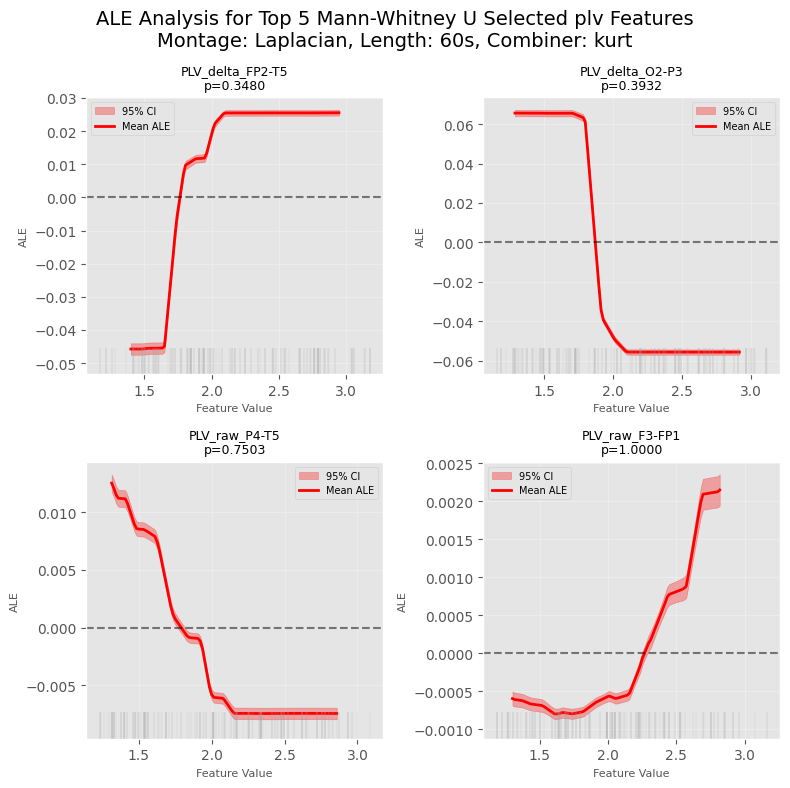


=== CREATING DETAILED INDIVIDUAL PLOTS WITH RUGPLOT ===


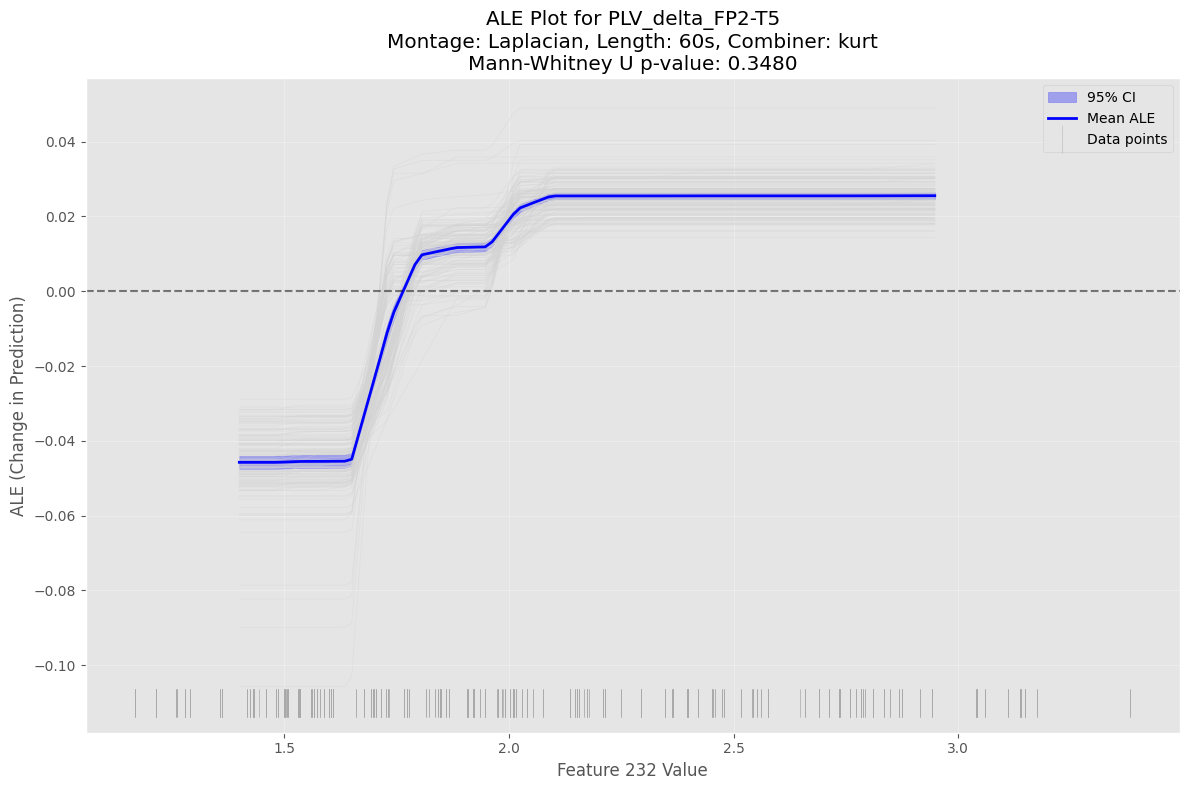

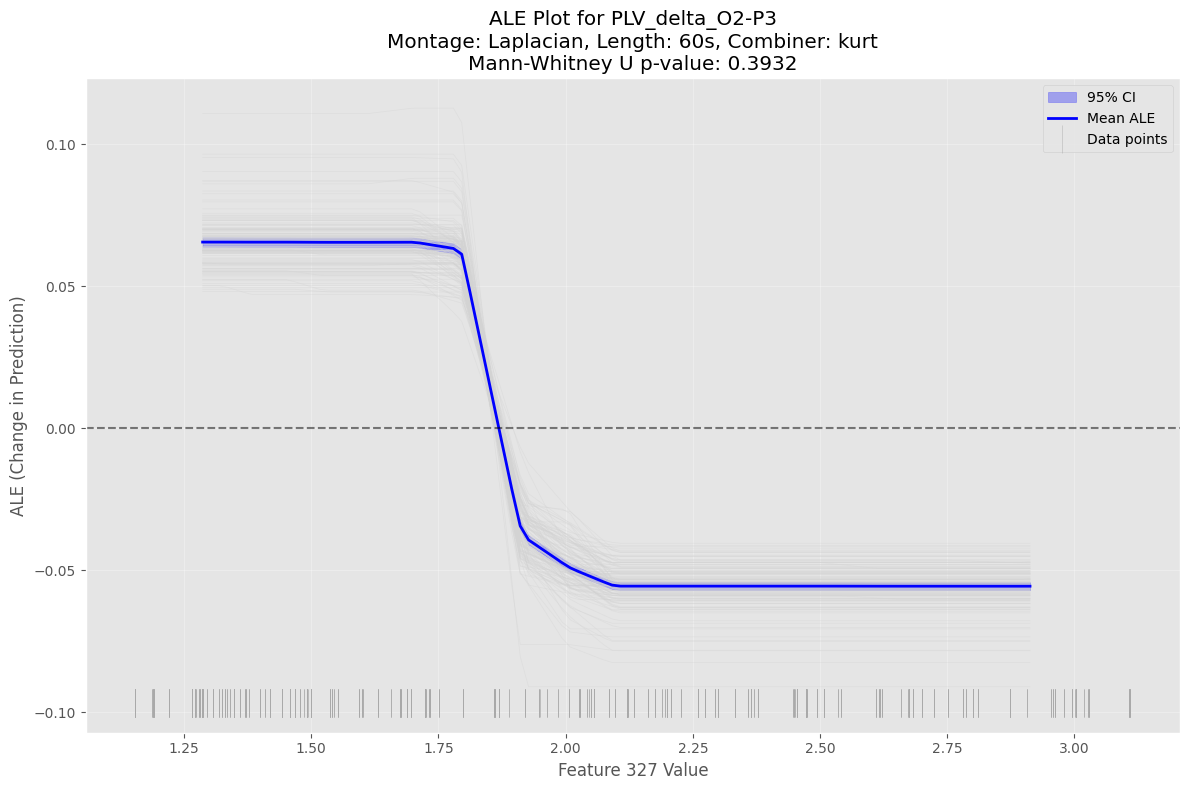

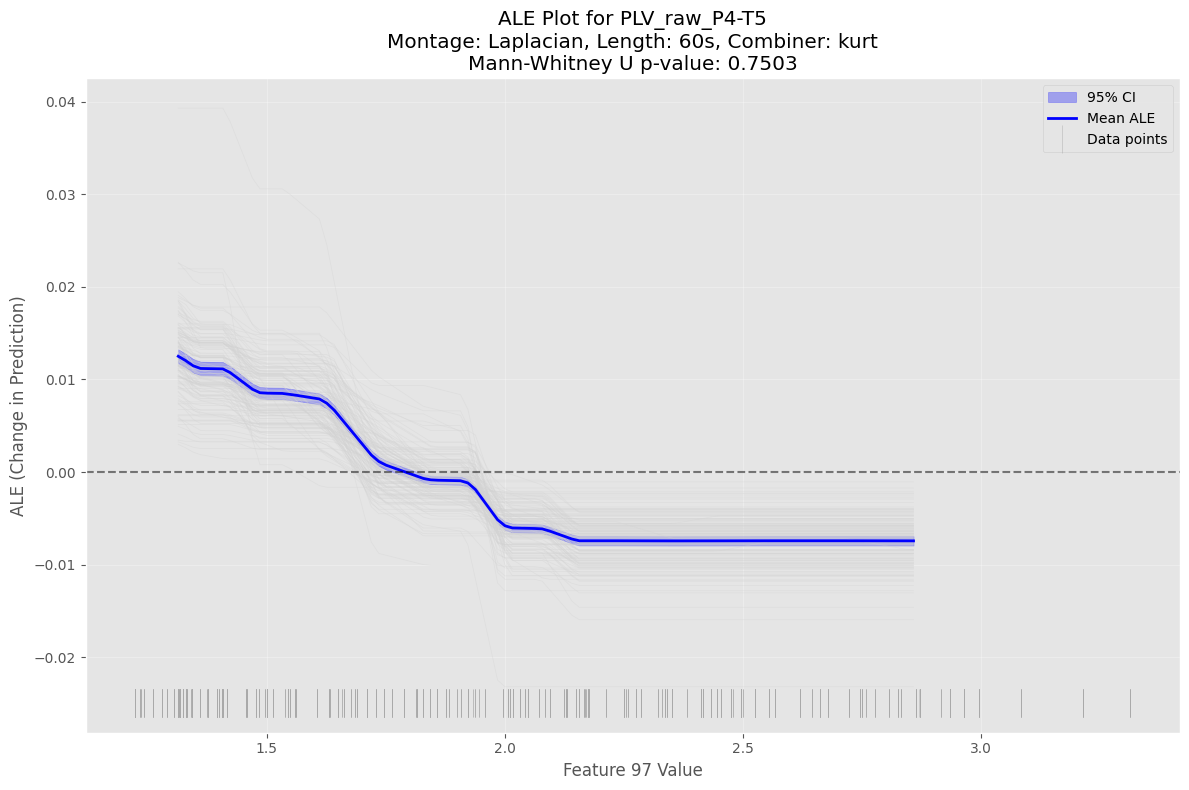

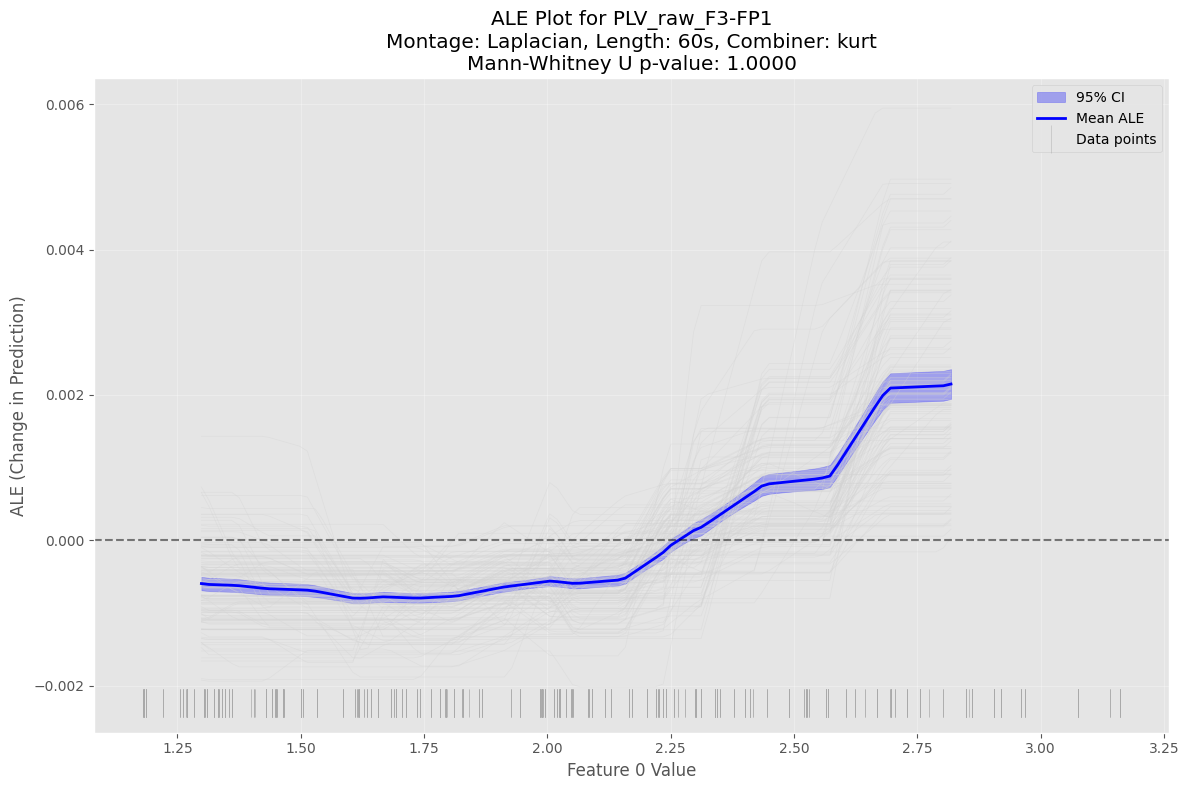

In [8]:
# Create plots using the prepared data (example usage)
print("\n=== CREATING PLOTS FROM PREPARED DATA ===")

if len(plot_data_collection) > 0:
    # Create overview plot with all top 5 features
    n_features = len(plot_data_collection)
    n_cols = min(2, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_features == 1:
        axes = [axes]
    elif n_rows == 1 and n_cols > 1:
        axes = axes.reshape(1, -1)

    # Sort by p-value (most significant first)
    sorted_features = sorted(plot_data_collection.items(),
                           key=lambda x: x[1]['p_value'])

    for i, (feat_idx, plot_data) in enumerate(sorted_features):
        if n_rows == 1 and n_cols > 1:
            ax = axes[0, i] if n_cols > 1 else axes[i]
        elif n_rows > 1 and n_cols == 1:
            ax = axes[i]
        elif n_rows > 1 and n_cols > 1:
            row, col = i // n_cols, i % n_cols
            ax = axes[row, col]
        else:
            ax = axes

        plt.sca(ax)

        # Plot using the prepared data
        valid_mask = plot_data['valid_mask']
        if np.any(valid_mask):
            ax.fill_between(plot_data['common_grid'][valid_mask],
                           plot_data['ci_lower'][valid_mask],
                           plot_data['ci_upper'][valid_mask],
                           alpha=0.3, color='red', label='95% CI')
            ax.plot(plot_data['common_grid'][valid_mask],
                   plot_data['mean_ale'][valid_mask],
                   'r-', linewidth=2, label='Mean ALE')
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

            # Add simple rugplot for overview
            if plot_data['feature_values'] is not None:
                valid_feature_vals = plot_data['feature_values'][~np.isnan(plot_data['feature_values'])]
                if len(valid_feature_vals) > 0:
                    y_min, y_max = ax.get_ylim()
                    rug_height = (y_max - y_min) * 0.02  # 2% of y-axis range
                    rug_y = y_min + rug_height

                    # Sample for overview plot
                    if len(valid_feature_vals) > 200:
                        sample_indices = np.random.choice(len(valid_feature_vals), 200, replace=False)
                        rug_values = valid_feature_vals[sample_indices]
                    else:
                        rug_values = valid_feature_vals

                    ax.plot(rug_values, np.full(len(rug_values), rug_y), '|',
                           color='darkgray', alpha=0.4, markersize=20, markeredgewidth=0.3)

        # Feature name and p-value
        if feat_idx < len(feature_names):
            title = f'{feature_names[feat_idx][:40]}\np={plot_data["p_value"]:.4f}'
        else:
            title = f'Feature {feat_idx}\np={plot_data["p_value"]:.4f}'

        ax.set_title(title, fontsize=9)
        ax.set_xlabel('Feature Value', fontsize=8)
        ax.set_ylabel('ALE', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

    # Hide empty subplots
    for i in range(len(plot_data_collection), n_rows * n_cols):
        if n_rows == 1 and n_cols > 1:
            axes[0, i].set_visible(False)
        elif n_rows > 1:
            row, col = i // n_cols, i % n_cols
            axes[row, col].set_visible(False)

    plt.suptitle(f'ALE Analysis for Top 5 Mann-Whitney U Selected {feature_name} Features\n'
                 f'Montage: {montage}, Length: {segment_length}s, Combiner: {combiner}',
                 fontsize=14)
    plt.tight_layout()
    plt.savefig(f'ale_overview_{feature_name}_top5_mann_whitney_emc.pdf',
               dpi=300, bbox_inches='tight')
    plt.show()

    # Create individual detailed plots for each feature with rugplot
    print("\n=== CREATING DETAILED INDIVIDUAL PLOTS WITH RUGPLOT ===")
    for feat_idx, plot_data in sorted_features:
        fig = plot_ale_from_data(
            plot_data,
            feature_names=feature_names,
            figsize=(12, 8),
            show_rugplot=True,
        )
        plt.show()

        # Save individual plot
        plt.savefig(f'ale_{feature_name}_feature_{feat_idx}_mann_whitney_emc.pdf',
                   dpi=300, bbox_inches='tight')
        plt.close()
else:
    print('No plot data available for plotting')

In [ ]:
# Final summary
print("\n" + "="*60)
print("=== FINAL SUMMARY: MANN-WHITNEY U ALE ANALYSIS ===")
print("="*60)

print(f"\nFeature type: {feature_name}")
print(f"Montage: {montage}, Segment length: {segment_length}s, Combiner: {combiner}")
print(f"Total features in dataset: {data.shape[1]}")
print(f"Total subjects (LOSO folds): {len(unique_subjects)}")

# Mann-Whitney U test results
n_significant_features = np.sum(mw_corrected_p_values < 0.05)
n_valid_tests = np.sum(mw_p_values < 1.0)
print(f"\nMann-Whitney U Test Results:")
print(f"  Features tested: {n_valid_tests}")
print(f"  Significant features (corrected p < 0.05): {n_significant_features}")
print(f"  Top features selected for ALE: {len(features_to_analyze)}")
print(f"  Successful ALE computations: {len(ale_results)}")

if len(ale_results) > 0:
    avg_folds = np.mean([results['n_folds'] for results in ale_results.values()])
    print(f"  Average successful folds per feature: {avg_folds:.1f}")
    
    # Report top 5 features
    print(f"\nTop 5 features by Mann-Whitney U test (analyzed):")
    for i, feat_idx in enumerate(top_features):
        if feat_idx in ale_results:
            p_val = ale_results[feat_idx]['corrected_p_value']
            n_folds = ale_results[feat_idx]['n_folds']
            
            # Calculate max ALE effect
            mean_ale = ale_results[feat_idx]['mean_ale']
            valid_mask = ~np.isnan(mean_ale)
            max_ale = np.max(np.abs(mean_ale[valid_mask])) if np.any(valid_mask) else 0
            
            if feat_idx < len(feature_names):
                feat_name = feature_names[feat_idx][:80] + "..." if len(feature_names[feat_idx]) > 80 else feature_names[feat_idx]
            else:
                feat_name = f"Feature_{feat_idx}"
            
            status = "✓ Successfully analyzed"
            print(f"  {i+1}. Feature {feat_idx}: {feat_name}")
            print(f"      Status: {status}")
            print(f"      Corrected p-value: {p_val:.2e}")
            print(f"      Max |ALE|: {max_ale:.4f}")
            print(f"      Successful folds: {n_folds}")
        else:
            status = "✗ ALE analysis failed"
            print(f"  {i+1}. Feature {feat_idx}: {status}")

print(f"\nAnalysis completed! Plot data available for {len(plot_data_collection)} features.")
print("="*60)


=== FINAL SUMMARY: MANN-WHITNEY U ALE ANALYSIS ===

Feature type: plv
Montage: Laplacian, Segment length: 60s, Combiner: kurt
Total features in dataset: 1026
Total subjects (LOSO folds): 141

Mann-Whitney U Test Results:
  Features tested: 1026
  Significant features (corrected p < 0.05): 0
  Top features selected for ALE: 4
  Successful ALE computations: 4
  Average successful folds per feature: 141.0

Top 5 features by Mann-Whitney U test (analyzed):
  1. Feature 232: PLV_delta_FP2-T5
      Status: ✓ Successfully analyzed
      Corrected p-value: 3.48e-01
      Max |ALE|: 0.0457
      Successful folds: 141
  2. Feature 327: PLV_delta_O2-P3
      Status: ✓ Successfully analyzed
      Corrected p-value: 3.93e-01
      Max |ALE|: 0.0656
      Successful folds: 141
  3. Feature 97: PLV_raw_P4-T5
      Status: ✓ Successfully analyzed
      Corrected p-value: 7.50e-01
      Max |ALE|: 0.0125
      Successful folds: 141
  4. Feature 0: PLV_raw_F3-FP1
      Status: ✓ Successfully analyzed
 

In [ ]:
# Plot data collection is the a dictionary where Each entry contains all necessary data for creating custom plots:
# - common_grid: x-axis values
# - mean_ale: main ALE curve  
# - ci_lower, ci_upper: confidence intervals
# - individual_folds: individual fold curves
# - feature metadata (name, index, p_value, etc.)

# Example of accessing the data:
if len(plot_data_collection) > 0:
    first_feature = list(plot_data_collection.keys())[0]
    sample_data = plot_data_collection[first_feature]
    print(f"Sample plot data structure for feature {first_feature}:")
    print(f"  Keys available: {list(sample_data.keys())}")
    print(f"  Grid points: {len(sample_data['common_grid'])}")
    print(f"  Valid ALE points: {np.sum(sample_data['valid_mask'])}")
    print(f"  Individual folds: {len(sample_data['individual_folds']) if sample_data['individual_folds'] else 0}")

Sample plot data structure for feature 232:
  Keys available: ['common_grid', 'mean_ale', 'std_ale', 'ci_lower', 'ci_upper', 'valid_mask', 'feature_name', 'feature_idx', 'montage', 'segment_length', 'combiner', 'individual_folds', 'p_value', 'feature_values']
  Grid points: 100
  Valid ALE points: 100
  Individual folds: 141
